In [ ]:
# Connexion Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/fraud_detection/creditcard.csv")

print(df.shape)
print(df['Class'].value_counts())

(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64


# Détection de fraude financière — Transactions bancaires

## Contexte du projet
La fraude par carte de crédit représente une perte majeure pour les institutions
financières. Ce projet construit un modèle capable de détecter automatiquement
les transactions frauduleuses parmi des centaines de milliers d'opérations.

## Source des données
- **Dataset** : Credit Card Fraud Detection (Kaggle — Machine Learning Group, ULB)
- **Période** : Transactions européennes de septembre 2013
- **Taille** : 284 807 transactions — 31 colonnes

## Problème métier
Sur 284 807 transactions :
- 284 315 sont normales (99.83%)
- 492 sont frauduleuses (0.17%)

Le dataset est **fortement déséquilibré** — un modèle naïf qui prédit
"normal" pour tout aurait 99.83% de précision sans détecter aucune fraude.
C'est pourquoi on utilisera le **Recall** comme métrique principale.

## Étape 1 — Exploration des données

**Pourquoi ?** Avant de construire un modèle, on doit comprendre
ce qu'on a : combien de lignes, quelles colonnes, y a-t-il des
valeurs manquantes ? Un modèle construit sur des données mal
comprises donnera de mauvais résultats.

**Comment ?** On utilise des fonctions Pandas qui donnent un
résumé rapide du dataset.

**But ?** Identifier les problèmes dans les données avant
de les traiter.

In [ ]:
print("=== FORME DU DATASET ===")
print(f"Lignes : {df.shape[0]}")
print(f"Colonnes : {df.shape[1]}")

print("\n=== TYPES ET VALEURS MANQUANTES ===")
print(df.info())

print("\n=== STATISTIQUES DESCRIPTIVES ===")
df.describe()

=== FORME DU DATASET ===
Lignes : 284807
Colonnes : 31

=== TYPES ET VALEURS MANQUANTES ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## Étape 2 — Normalisation des données

**Pourquoi ?**
Les colonnes V1 à V28 sont déjà centrées autour de zéro grâce à la
transformation PCA (Analyse en Composantes Principales). Par contre,
`Amount` peut atteindre 25 691 et `Time` atteint 172 792.
Sans correction, le modèle accorderait trop d'importance à ces deux
colonnes à cause de leur échelle — pas parce qu'elles sont plus utiles.Parce qu'elles n'ont pas ete normaliser par le PCA

**Comment ?**
On utilise `StandardScaler` de Scikit-learn. Cette fonction transforme
chaque valeur selon la formule :
valeur_normalisée = (valeur - moyenne) / écart-type
Résultat : toutes les valeurs sont centrées autour de 0 avec
un écart-type de 1.

**But ?**
Mettre toutes les colonnes(Time et Amount) sur la même échelle pour que le modèle
puisse les comparer équitablement.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])

# Supprimer les colonnes originales
df = df.drop(['Amount', 'Time'], axis=1)

print(df.shape)
print(df[['Amount_scaled', 'Time_scaled']].describe())

(284807, 31)
       Amount_scaled   Time_scaled
count   2.848070e+05  2.848070e+05
mean    2.913952e-17 -3.065637e-16
std     1.000002e+00  1.000002e+00
min    -3.532294e-01 -1.996583e+00
25%    -3.308401e-01 -8.552120e-01
50%    -2.652715e-01 -2.131453e-01
75%    -4.471707e-02  9.372174e-01
max     1.023622e+02  1.642058e+00


## Étape 3 — Séparation X / y et découpage Train/Test

**Pourquoi ?**
Un modèle Machine Learning apprend à partir d'exemples.
Pour évaluer honnêtement ses performances, on ne peut pas
le tester sur les mêmes données qu'il a utilisées pour apprendre —
ce serait comme donner les réponses à un élève avant l'examen.

On sépare donc les données en deux parties :
- **Train (80%)** : le modèle apprend sur ces données
- **Test (20%)** : on évalue le modèle sur des données qu'il n'a jamais vues

**Comment ?**
- X contient toutes les colonnes sauf `Class` (les variables prédictives)
- y contient uniquement `Class` (0 = normal, 1 = fraude)
- `train_test_split` divise automatiquement en 80% / 20%
- `stratify=y` garantit que le déséquilibre des classes
  est conservé dans les deux parties

**But ?**
Avoir des données d'entraînement et des données de test
propres pour construire et évaluer le modèle honnêtement.

In [ ]:
from sklearn.model_selection import train_test_split

# Séparation X / y
X = df.drop('Class', axis=1)
y = df['Class']

# Découpage Train / Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train : {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"Fraudes dans y_train : {y_train.sum()}")
print(f"Fraudes dans y_test : {y_test.sum()}")

X_train : (227845, 30)
X_test : (56962, 30)
Fraudes dans y_train : 394
Fraudes dans y_test : 98


## Étape 4 — Construction du modèle Random Forest

**Pourquoi ?**
Le Random Forest est un modèle robuste qui fonctionne bien sur
les données déséquilibrées. Il construit plusieurs arbres de décision
indépendants et combine leurs résultats — ce qui réduit les erreurs.

Le paramètre `class_weight='balanced'` est crucial ici : il dit au
modèle de pénaliser davantage les erreurs sur les fraudes (classe
minoritaire) que sur les transactions normales.
Sans ce paramètre, le modèle ignorerait les fraudes.

**Comment ?**
On entraîne le modèle sur X_train et y_train uniquement.
Le modèle apprend les patterns qui distinguent une fraude
d'une transaction normale.

**But ?**
Construire un modèle capable de détecter les fraudes
avec un Recall élevé.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Modèle entraîné avec succès.")
print(f"Nombre d'arbres : {model.n_estimators}")

Modèle entraîné avec succès.
Nombre d'arbres : 100


## Étape 5 — Évaluation du modèle

**Pourquoi ?**
Un modèle entraîné ne vaut rien si on ne mesure pas ses performances
sur des données qu'il n'a jamais vues. On utilise X_test et y_test
— les 20% mis de côté depuis le début.

**Comment ?**
On utilise trois outils d'évaluation :
- `confusion_matrix` : tableau qui montre combien de fraudes
  ont été détectées et combien ont été manquées
- `classification_report` : affiche Précision, Recall et F1-Score
  pour chaque classe
- `roc_auc_score` : mesure globale de la qualité du modèle
  (1.0 = parfait, 0.5 = aléatoire)

**But ?**
Vérifier que le modèle détecte bien les fraudes (Recall élevé)
et comprendre ses limites.

---

### La matrice de confusion — 4 cas possibles

| Cas | Nom technique | Signification |
|---|---|---|
| Fraude détectée comme fraude | Vrai Positif (TP) | ✅ Bonne détection |
| Normal détecté comme normal | Vrai Négatif (TN) | ✅ Bonne détection |
| Fraude détectée comme normale | Faux Négatif (FN) | ❌ Fraude manquée |
| Normal détecté comme fraude | Faux Positif (FP) | ❌ Fausse alarme |

Le **Faux Négatif (FN)** est l'erreur la plus grave :
une vraie fraude que le modèle n'a pas détectée = argent volé.

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# Prédictions sur les données de test
y_pred = model.predict(X_test)

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
print("=== MATRICE DE CONFUSION ===")
print(cm)

# Rapport complet
print("\n=== RAPPORT DE CLASSIFICATION ===")
print(classification_report(y_test, y_pred))

# Score AUC-ROC
auc = roc_auc_score(y_test, y_pred)
print(f"AUC-ROC Score : {auc:.4f}")

=== MATRICE DE CONFUSION ===
[[56861     3]
 [   24    74]]

=== RAPPORT DE CLASSIFICATION ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.76      0.85        98

    accuracy                           1.00     56962
   macro avg       0.98      0.88      0.92     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC Score : 0.8775


## Étape 6 — Amélioration du Recall par ajustement du seuil

**Analyse de nos résultats précédents**
Notre modèle avec le seuil par défaut (0.5) a donné :
- Precision : 96% → quand il accuse une transaction d'être
  une fraude, il a raison 96% du temps
- Recall : 76% → il détecte seulement 76 fraudes sur 100

Il y a une anomalie entre ces deux métriques :
le modèle est très précis quand il accuse (96%) mais il
rate 24 fraudes sur 100 (Recall 76%). Autrement dit, il est
trop "prudent" — il préfère ne pas accuser plutôt que de
se tromper. Dans le contexte d'une banque, ce comportement
est dangereux : chaque fraude manquée = argent volé au client.

**Pourquoi ?**
Par défaut le modèle utilise un seuil de 0.5 : il déclare
"fraude" uniquement si la probabilité dépasse 50%.
En abaissant ce seuil à 0.3, le modèle devient plus méfiant
et détecte plus de fraudes — au prix de plus de fausses alarmes.

**Comment ?**
On utilise `predict_proba()` qui retourne la probabilité
que chaque transaction soit une fraude, puis on applique
manuellement notre seuil de 0.3.

**But ?**
Augmenter le Recall pour manquer moins de fraudes réelles.

**Compromis Precision / Recall**
| Seuil | Effet sur Recall | Effet sur Precision |
|---|---|---|
| 0.5 (défaut) | 76% | 96% |
| 0.3 (nouveau) | ↑ Augmente | ↓ Diminue |

In [ ]:
import numpy as np

# Probabilités de fraude pour chaque transaction
y_proba = model.predict_proba(X_test)[:, 1]

# Appliquer le seuil de 0.3
y_pred_adjusted = (y_proba >= 0.3).astype(int)

# Évaluation
print("=== AVEC SEUIL 0.3 ===")
print(confusion_matrix(y_test, y_pred_adjusted))
print(classification_report(y_test, y_pred_adjusted))

=== AVEC SEUIL 0.3 ===
[[56859     5]
 [   18    80]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



**Résultats obtenus**

| Métrique | Seuil 0.5 | Seuil 0.3 |
|---|---|---|
| Precision | 96% | 94% |
| Recall | 76% | 82% |
| Fraudes manquées | 24 | 18 |
| Fausses alarmes | 3 | 5 |

Le seuil 0.3 détecte 6 fraudes supplémentaires au prix
de seulement 2 fausses alarmes en plus.
Pour une banque, ce compromis est acceptable :
une fausse alarme se règle avec un appel au client,
une fraude manquée cause une perte financière réelle.

## Étape 7 — Visualisation des résultats

**Pourquoi ?**

Une visualisation
permet de communiquer les résultats clairement et rapidement.

**Comment ?**
On produit deux graphiques :
1. **Matrice de confusion visuelle** : montre en couleurs
   combien de fraudes ont été détectées et manquées
2. **Importance des variables** : montre quelles colonnes
   le modèle utilise le plus pour détecter les fraudes

**But ?**
Rendre les résultats compréhensibles par tout le monde

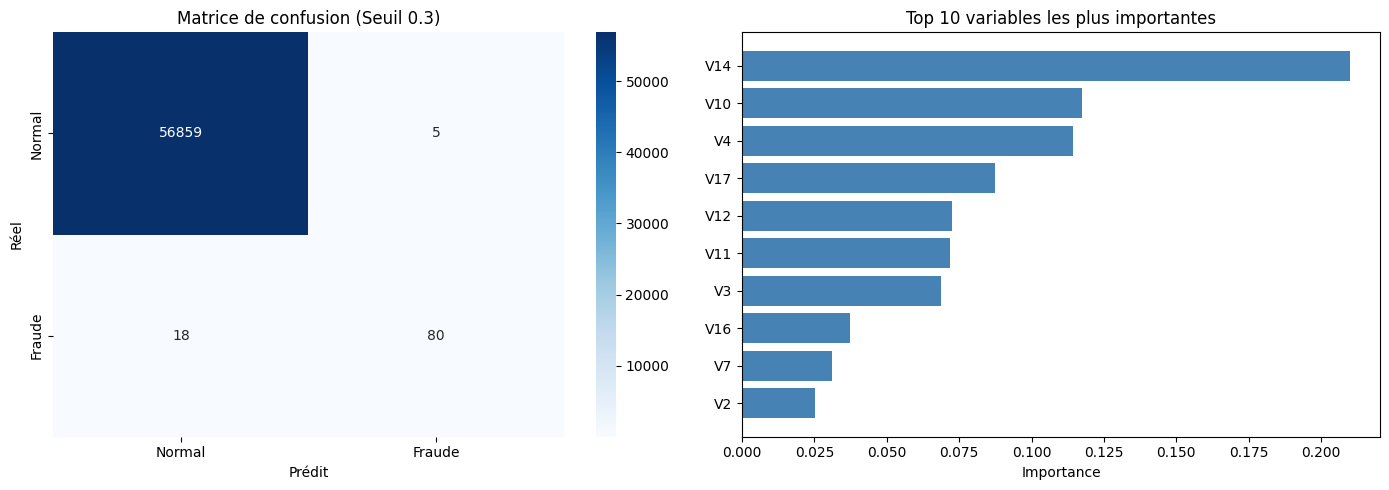

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# === GRAPHIQUE 1 : Matrice de confusion ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice de confusion seuil 0.3
cm_adjusted = confusion_matrix(y_test, y_pred_adjusted)
sns.heatmap(cm_adjusted, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraude'],
            yticklabels=['Normal', 'Fraude'],
            ax=axes[0])
axes[0].set_title('Matrice de confusion (Seuil 0.3)')
axes[0].set_ylabel('Réel')
axes[0].set_xlabel('Prédit')

# === GRAPHIQUE 2 : Importance des variables ===
importances = model.feature_importances_
features = X.columns
indices = np.argsort(importances)[::-1][:10]

axes[1].barh(range(10), importances[indices][::-1], color='steelblue')
axes[1].set_yticks(range(10))
axes[1].set_yticklabels(features[indices][::-1])
axes[1].set_title('Top 10 variables les plus importantes')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

## Interprétation des résultats visuels

---

### Graphique 1 — Matrice de confusion (Seuil 0.3)

La matrice de confusion se lit comme un tableau de vérité :
les lignes représentent la réalité, les colonnes représentent
ce que le modèle a prédit.

| | Prédit Normal | Prédit Fraude |
|---|---|---|
| **Réel Normal** | 56 859  | 5  |
| **Réel Fraude** | 18  | 80 |

**Lecture case par case :**

- **56 859 (en haut à gauche)** : transactions normales correctement
  identifiées comme normales. Le modèle n'a pas déclenché d'alarme
  inutile sur ces clients — c'est la grande majorité des cas.

- **5 (en haut à droite)** : fausses alarmes — des transactions
  normales accusées à tort d'être des fraudes.
  Conséquence : un appel au client pour vérification.
  Gênant mais pas grave.

- **18 (en bas à gauche)** : fraudes manquées — des vraies fraudes
  que le modèle n'a pas détectées.
  Conséquence : argent volé au client, perte pour la banque.
  C'est l'erreur la plus grave.

- **80 (en bas à droite)** : fraudes correctement détectées.
  Sur 98 fraudes réelles, le modèle en a attrapé 80 — soit un
  Recall de 82%.

**Conclusion :** Le modèle est très performant sur les transactions
normales (quasi zéro erreur sur 56 864 cas) et détecte 82% des
fraudes réelles. Il reste 18 fraudes manquées à améliorer.

---

### Graphique 2 — Top 10 variables les plus importantes

Ce graphique montre quelles variables le modèle utilise le plus
pour prendre ses décisions. Plus la barre est longue, plus la
variable influence les prédictions.

**Variables clés :**

- **V14 (importance ≈ 0.20)** : la variable la plus déterminante
  du modèle. Les transactions frauduleuses ont des valeurs de V14
  très différentes des transactions normales. Le modèle s'appuie
  sur elle en priorité pour détecter les fraudes.

- **V10 (importance ≈ 0.12)** et **V4 (importance ≈ 0.11)** :
  deuxième et troisième variables les plus importantes.
  Elles complètent V14 pour affiner la détection.

- **V17, V12, V11, V3, V16, V7, V2** : variables secondaires qui
  contribuent chacune modestement à la décision finale.

**Remarque importante :** Ces variables sont anonymisées par PCA
— on ne connaît pas leur signification réelle dans les données
bancaires originales. C'est une limite de ce dataset :
la confidentialité des données a été préservée au prix
de l'interprétabilité.

**Conclusion :** Le modèle ne s'appuie pas sur une seule variable
mais sur une combinaison de plusieurs signaux. C'est ce qui le
rend robuste — si V14 est absente ou manipulée par un fraudeur,
V10 et V4 compensent.